# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import os

import random

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
torch.cuda.is_available()

True

# Import Data

Classes: ['ai', 'real']
Number of training images: 500
Number of validation images: 2000
Number of test images: 20000


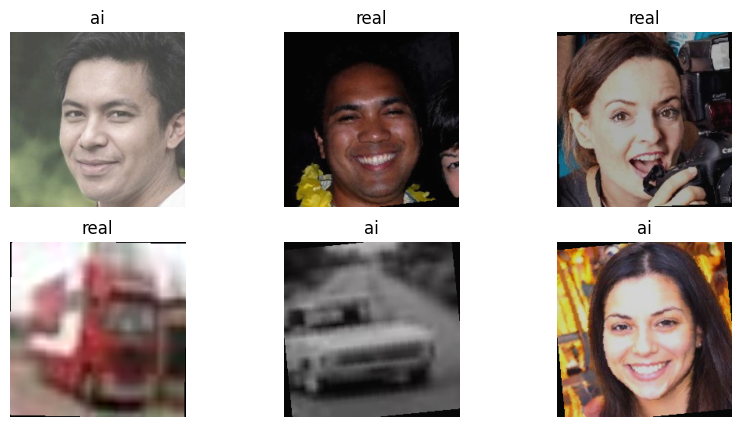

In [4]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)

# Training: resize, augmentation, normalization
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize
])

# Validation & Test: resize + normalization only
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])


train_dataset = datasets.ImageFolder(
    root="mix_data/train_10",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="mix_data/val_10",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root="mix_data/test",
    transform=val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_loader))
print("Number of validation images:", len(valid_dataset))
print("Number of test images:", len(test_dataset))

images, labels = next(iter(train_loader))
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i] * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    img = img.clamp(0,1) 
    plt.imshow(img.permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

In [36]:
# import os
# import random
# import shutil

# def create_subset(src_dir, dst_dir, fraction=0.1, seed=42):
#     random.seed(seed)
#     os.makedirs(dst_dir, exist_ok=True)
    
#     files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
#     random.shuffle(files)
    
#     k = max(1, round(len(files) * fraction))
    
#     print(f"Selecting {k}/{len(files)} files")
    
#     for fname in files[:k]:
#         shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))


In [46]:
# create_subset("mix_data/val/ai", "mix_data/val_10/ai", fraction=0.1)
# create_subset("mix_data/val/real", "mix_data/val_10/real", fraction=0.1)

Selecting 1000/10000 files
Selecting 1000/10000 files


# Model Training (ResNet-18)

In [5]:
import torch
import torch.nn as nn
from torchvision import models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [9]:
best_valid_acc = 0
best_valid_round = 0

start_time = time.time()

training_loss = []
training_acc = []
validation_loss = []
validation_acc = []

for epoch in range(10):
    print(f"Epoch {epoch+1}")
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    training_loss.append(train_loss)
    training_acc.append(train_acc)
    validation_loss.append(valid_loss)
    validation_acc.append(valid_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Validation Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.4f}")

    torch.save(model.state_dict(), f"new_resnet18_epoch_{epoch+1}.pth")

    if valid_acc > best_valid_acc: 
        best_valid_acc = valid_acc
        best_valid_round = epoch + 1

    print(f"epoch time: {time.time() - start_time}\n")
        
print("Best epoch: ", best_valid_round)
print("Best validation", best_valid_acc)
print("Total time: ", time.time() - start_time)

Epoch 1
ERROR! Session/line number was not unique in database. History logging moved to new session 1025
Train Loss: 0.3681, Train Acc: 0.8319
Validation Loss: 0.2702, Val Acc: 0.8825
epoch time: 247.47141909599304

Epoch 2
Train Loss: 0.2454, Train Acc: 0.8971
Validation Loss: 0.2725, Val Acc: 0.8945
epoch time: 350.1672737598419

Epoch 3
Train Loss: 0.1851, Train Acc: 0.9274
Validation Loss: 0.2182, Val Acc: 0.9180
epoch time: 451.14820432662964

Epoch 4
Train Loss: 0.1567, Train Acc: 0.9374
Validation Loss: 0.1982, Val Acc: 0.9265
epoch time: 550.9504008293152

Epoch 5
Train Loss: 0.1240, Train Acc: 0.9514
Validation Loss: 0.2095, Val Acc: 0.9170
epoch time: 648.701694726944

Epoch 6
Train Loss: 0.1068, Train Acc: 0.9590
Validation Loss: 0.1471, Val Acc: 0.9460
epoch time: 746.3609755039215

Epoch 7
Train Loss: 0.0893, Train Acc: 0.9675
Validation Loss: 0.2284, Val Acc: 0.9270
epoch time: 844.6402759552002

Epoch 8
Train Loss: 0.0933, Train Acc: 0.9661
Validation Loss: 0.2337, Val A

In [10]:
@torch.no_grad()
def test(model, loader, criterion, device):
    model.eval()
    
    y_true = []
    y_pred = []
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)

    return avg_loss, y_true, y_pred

In [11]:
model.load_state_dict(torch.load("new_resnet18_epoch_9.pth", map_location=device))

test_loss, y_true, y_pred = test(model, test_loader, criterion, device)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

Loss     : 0.1442
Accuracy : 0.9516
Precision: 0.9478
Recall   : 0.9559
F1-score : 0.9519
AUC-ROC : 0.9516


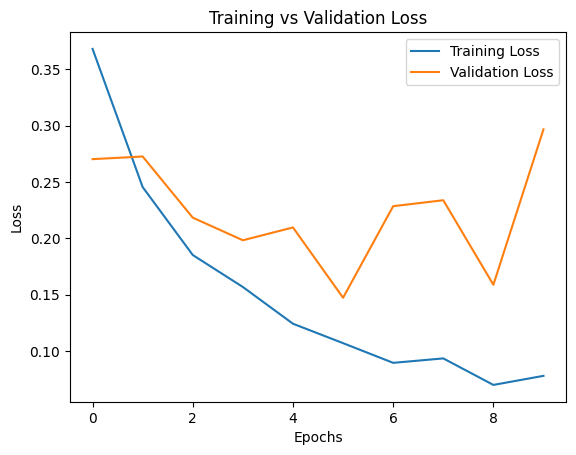

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

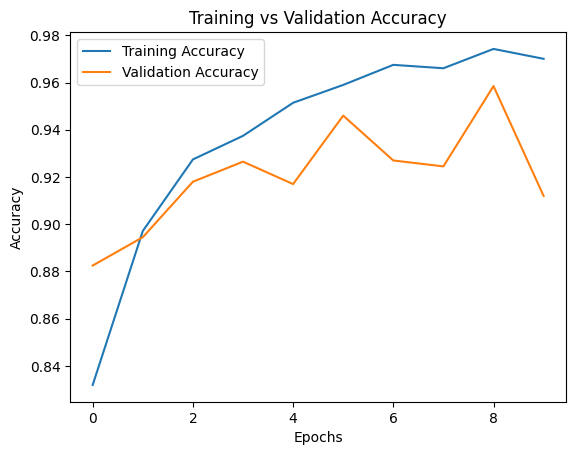

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(training_acc, label='Training Accuracy')
plt.plot(validation_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()